In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('Pakistani_Diabetes_Dataset.csv')
print(df.head())
print(df.info())
print(df.describe())

    Age  Gender  Rgn     wt    BMI   wst  sys  dia  his   A1c  B.S.R  vision  \
0  60.0       1     0  76.0  29.90  41.0  130   90    0  8.90    278       0   
1  57.0       1     1  64.0  24.30  39.0  120   80    1  8.50    165       0   
2  58.0       0     0  73.0  25.20  34.0  140   90    0  5.65    130       1   
3  27.0       0     1  60.0  22.01  30.0  110   70    0  5.00     95       0   
4  56.0       1     0  70.0  25.80  43.0  125   90    0  8.30    139       1   

   Exr  dipsia  uria   Dur  neph  HDL  Outcome  
0   30       1     0   5.0     0   60        1  
1   20       1     1  20.0     0   42        1  
2   20       0     0   0.0     0   54        0  
3   15       0     0   0.0     0   57        0  
4   40       1     0   5.0     1   53        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Age      912 non-null    float64
 1   G

In [5]:
df.rename(columns={
    'wt':     'Weight',
    'wst':    'Waist',
    'sys':    'SysBP',
    'dia':    'DiaBP',
    'his':    'FamilyHistory',
    'B.S.R':  'BloodSugar',
    'Exr':    'Exercise',
    'dipsia': 'ExcessThirst',
    'uria':   'FreqUrination',
    'Dur':    'DiabetesDuration',
    'neph':   'KidneyIssue',
    'Rgn':    'Region'
}, inplace=True)

print(df.columns)

Index(['Age', 'Gender', 'Rgn ', 'Weight', 'BMI', 'Waist', 'SysBP', 'DiaBP',
       'FamilyHistory', 'A1c', 'BloodSugar', 'vision', 'Exercise',
       'ExcessThirst', 'FreqUrination', 'DiabetesDuration', 'KidneyIssue',
       'HDL', 'Outcome'],
      dtype='object')


In [6]:
df

,Age,Gender,Rgn,Weight,BMI,Waist,SysBP,DiaBP,FamilyHistory,A1c,BloodSugar,vision,Exercise,ExcessThirst,FreqUrination,DiabetesDuration,KidneyIssue,HDL,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,22.0,0,0,54.0,17.08,40.0,143,85,1,5.00,165,0,15,0,0,0.0,0,54,0
908,32.0,0,1,52.0,18.50,28.0,138,95,1,4.70,87,0,0,0,0,0.0,0,54,0
909,22.0,0,0,78.0,26.14,32.0,183,88,1,4.50,100,0,0,1,0,0.0,0,40,1
910,18.0,1,1,53.0,20.05,33.0,195,93,1,4.70,74,1,15,0,0,0.0,0,46,0


In [7]:
def age_group(age):
    if age <= 20:
        return 'Young (<=20)'
    elif age <= 40:
        return 'Adult (21-40)'
    elif age <= 60:
        return 'Middle Age (41-60)'
    else:
        return 'Senior (60+)'

df['AgeGroup'] = df['Age'].apply(age_group)
print(df['AgeGroup'].value_counts())

AgeGroup
Adult (21-40)         485
Middle Age (41-60)    348
Young (<=20)           54
Senior (60+)           25
Name: count, dtype: int64


In [8]:
# Insight 1:
# Age is a strong factor for diabetes - Increasing age is a major risk factor for diabetes.

df.groupby('Outcome')['Age'].mean()

Outcome
0    25.286385
1    45.988683
Name: Age, dtype: float64

In [9]:
df.groupby('Gender')['Outcome'].mean()

Gender
0    0.354523
1    0.677932
Name: Outcome, dtype: float64

In [10]:
# Insight 3: there is a relation between age and diabetes
# Young have 4%
# Senior 100% diabetic
# more age= more danger for diabetes

df.groupby('AgeGroup')['Outcome'].mean()

AgeGroup
Adult (21-40)         0.284536
Middle Age (41-60)    0.922414
Senior (60+)          1.000000
Young (<=20)          0.037037
Name: Outcome, dtype: float64

In [11]:
# Insight 4:
# A1c bhi 8.5 vs 4.9 — almost double
# Blood Sugar and A1c diabetes are strongest indicators for diabetes

df.groupby('Outcome')[['BloodSugar','A1c']].mean()

,BloodSugar,A1c
Outcome,,
0,98.201878,4.956901
1,224.436214,8.528004


In [12]:
# Insight 5: Exercise is a weak factor

df.groupby('Outcome')['Exercise'].mean()


Outcome
0    15.622066
1    13.384774
Name: Exercise, dtype: float64

In [13]:
# Insight 6: Family history is also a weak indicator
df.groupby('FamilyHistory')['Outcome'].mean()*100

FamilyHistory
0    45.238095
1    58.988764
Name: Outcome, dtype: float64

In [14]:
print("="*50)
print("KEY INSIGHTS - Pakistani Diabetes Analysis")
print("="*50)
print("1. Diabetic avg age: 46 vs Non-diabetic: 25")
print("2. Males: 68% diabetic vs Females: 35%")
print("3. Senior patients: 100% diabetic!")
print("4. Blood Sugar: 224 (diabetic) vs 98 (normal)")
print("5. Exercise: weak factor (15 vs 13 min)")
print("6. Family history: 59% vs 45% risk")
print("="*50)

KEY INSIGHTS - Pakistani Diabetes Analysis
1. Diabetic avg age: 46 vs Non-diabetic: 25
2. Males: 68% diabetic vs Females: 35%
3. Senior patients: 100% diabetic!
4. Blood Sugar: 224 (diabetic) vs 98 (normal)
5. Exercise: weak factor (15 vs 13 min)
6. Family history: 59% vs 45% risk


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries ready!")

Libraries ready!


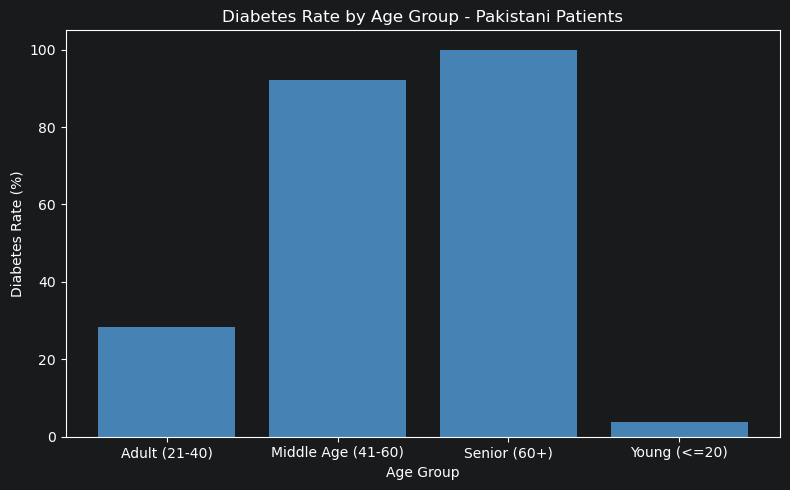

In [16]:

age_diabetes = df.groupby('AgeGroup')['Outcome'].mean() * 100


plt.figure(figsize=(8, 5))
plt.bar(age_diabetes.index, age_diabetes.values, color='steelblue')


plt.title('Diabetes Rate by Age Group - Pakistani Patients')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')


plt.tight_layout()
plt.show()

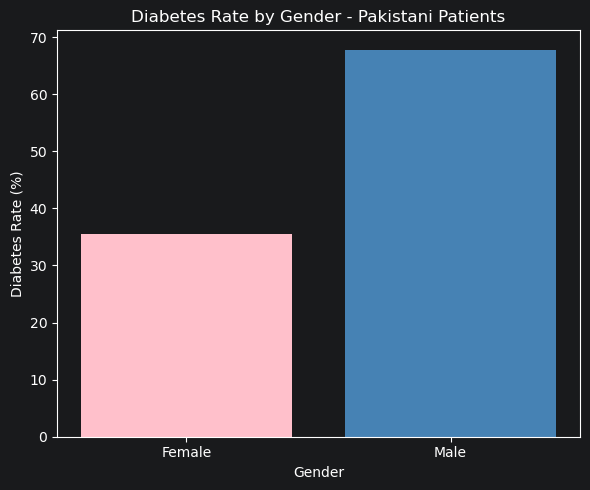

In [17]:
gender_diabetes = df.groupby('Gender')['Outcome'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(['Female', 'Male'], gender_diabetes.values,
        color=['pink', 'steelblue'])

plt.title('Diabetes Rate by Gender - Pakistani Patients')
plt.xlabel('Gender')
plt.ylabel('Diabetes Rate (%)')

plt.tight_layout()
plt.show()

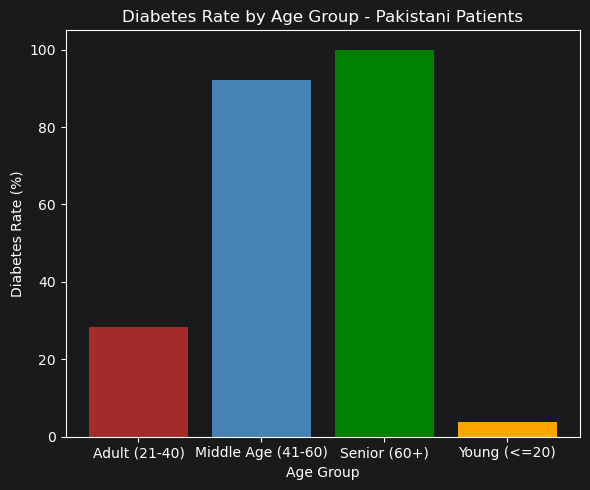

In [18]:
senior_diabetes = df.groupby('AgeGroup')['Outcome'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(senior_diabetes.index, senior_diabetes.values,
        color=['brown', 'steelblue', 'green', 'orange'])

plt.title('Diabetes Rate by Age Group - Pakistani Patients')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')

plt.tight_layout()
plt.show()

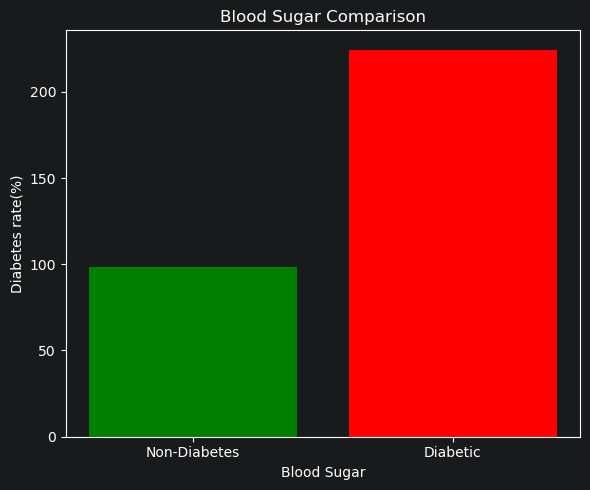

In [19]:
bloodSugar_data = df.groupby('Outcome')['BloodSugar'].mean()
plt.figure(figsize=(6,5))
plt.bar(['Non-Diabetes','Diabetic'],bloodSugar_data.values,color=['green', 'red'] )

plt.title('Blood Sugar Comparison')
plt.xlabel('Blood Sugar')
plt.ylabel('Diabetes rate(%)')

plt.tight_layout()
plt.show()

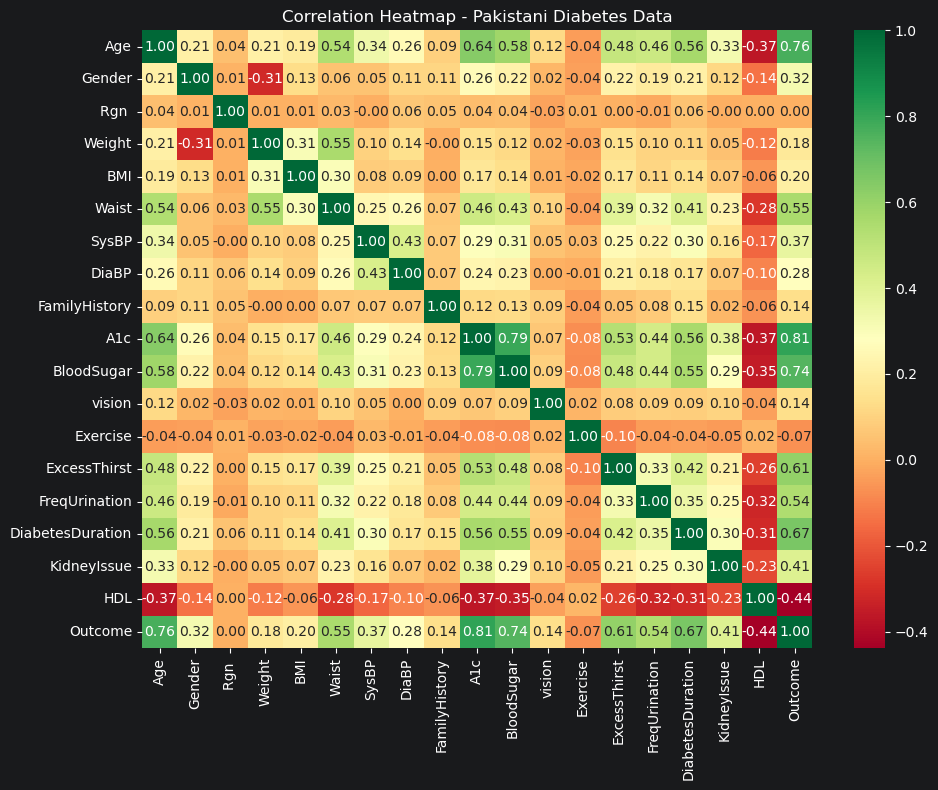

In [20]:

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='RdYlGn')

plt.title('Correlation Heatmap - Pakistani Diabetes Data')
plt.tight_layout()
plt.show()

In [21]:
# Insight 7: A1c (0.81) and BloodSugar (0.74) are strongest indicators for diabetes
# HDL negative relation — more HDL = less diabetes risk

C:\Users\user\AppData\Local\Temp\ipykernel_24324\2467560504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome',


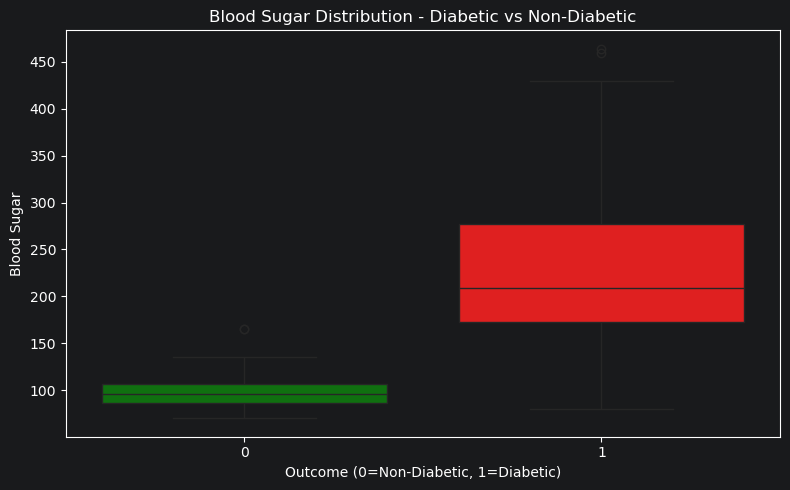

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome',
            y='BloodSugar',
            data=df,
            palette=['green', 'red'])

plt.title('Blood Sugar Distribution - Diabetic vs Non-Diabetic')
plt.xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.ylabel('Blood Sugar')
plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("   PAKISTANI DIABETES DATA ANALYSIS - CONCLUSIONS")
print("=" * 60)

print("""
📊 DATASET: 912 Pakistani Diabetes Patients

🔍 KEY FINDINGS:

1. AGE IS THE STRONGEST FACTOR:
   - Young (<=20)      → only 4% diabetic
   - Middle Age (41-60)→ 92% diabetic
   - Senior (60+)      → 100% diabetic
   - Increasing age is a major risk factor for diabetes.

2. GENDER MATTERS:
   - Males  → 68% diabetic
   - Females→ 35% diabetic
   - Males has  almost double diabetes

3. BLOOD SUGAR & A1c STRONGEST INDICATORS:
   - Non-Diabetic: Blood Sugar 98,  A1c 4.9
   - Diabetic:     Blood Sugar 224, A1c 8.5
   - Both are almost 2x more diabetic

4. FAMILY HISTORY HAS MODERATE EFFECT:
   - With history   → 59% diabetic
   - Without history→ 45% diabetic
   - 14% extra risk

5. EXERCISE HAS WEAK EFFECT:
   - Non-Diabetic: 15 min avg exercise
   - Diabetic:     13 min avg exercise
   - Difference is very less

💡 RECOMMENDATION:
   Pakistani males aged 40 and above with elevated
   Blood Sugar and A1c levels should prioritize
   regular diabetes screening.
""")

print("=" * 60)
print("   Analysis by: [Faiza]")
print("   Dataset: Pakistani Diabetes Dataset")
print("   Tools: Python, Pandas, NumPy, Matplotlib, Seaborn")
print("=" * 60)

   PAKISTANI DIABETES DATA ANALYSIS - CONCLUSIONS

📊 DATASET: 912 Pakistani Diabetes Patients

🔍 KEY FINDINGS:

1. AGE IS THE STRONGEST FACTOR:
   - Young (<=20)      → only 4% diabetic
   - Middle Age (41-60)→ 92% diabetic
   - Senior (60+)      → 100% diabetic
   - Increasing age is a major risk factor for diabetes.

2. GENDER MATTERS:
   - Males  → 68% diabetic
   - Females→ 35% diabetic
   - Males has  almost double diabetes

3. BLOOD SUGAR & A1c STRONGEST INDICATORS:
   - Non-Diabetic: Blood Sugar 98,  A1c 4.9
   - Diabetic:     Blood Sugar 224, A1c 8.5
   - Both are almost 2x more diabetic

4. FAMILY HISTORY HAS MODERATE EFFECT:
   - With history   → 59% diabetic
   - Without history→ 45% diabetic
   - 14% extra risk

5. EXERCISE HAS WEAK EFFECT:
   - Non-Diabetic: 15 min avg exercise
   - Diabetic:     13 min avg exercise
   - Difference is very less

💡 RECOMMENDATION:
   Pakistani males aged 40 and above with elevated
   Blood Sugar and A1c levels should prioritize
   regular d